This notebook assumes knowledge from the notebook `analytical_pricer.ipynb` in which full derivation and explainations of the formulae used below are discussed. 

Let us look back at the formula that we derived for calculating the terminal price of the option: $$ \boxed{S_T = S_0\exp\left[\left(\mu-\frac{\sigma^2}{2}\right)T+\sigma Z\sqrt{T} \right] \quad Z\sim\mathcal{N}(0,1)}$$ This is what we will be using to simulate the prices of the stock after some time $T$. The function `simulate_S_T` in `pricer.py` does exactly this, using `generate_normals` to produce an `np.array` of `n` i.i.d samples of the standard normal distribution: $Z\sim \mathcal{N}(0,1)$, and then returning us an `np.array` of `n` simulated final prices of the stock $(S_T)$ the option is based upon. From this, we can find the payoff for each simulated $S_T$ that the option would give us, this would be: 
1. **Call Option**: For the $i$th $S_T$ the payoff would be given by $P_i = \max\left\{0, S_T^{(i)}-K\right\}$
2. **Put Option**: For the $i$th $S_T$ the payoff would be given by $P_i = \max\left\{0, K-S_T^{(i)}\right\}$

From this we can find the average payoff, and discount it back to the current time at the risk-free rate $r$ to prevent arbitrage, giving us the valuation of our option right now: $$\hat{V}_0 = e^{-rT}\cdot \frac{1}{n}\sum_{i = 1}^{n}P_i$$ Note that we will denote the analytically obtained price using $V_0$ and the experimentally obtained price using $\hat{V}_0$. Let's compare this method of pricing to our analytical pricer.

In [1]:
from black_scholes.analytical import bs_call, bs_put
import monte_carlo.pricer as pricer
import monte_carlo.variance_reduction as anti_pricer
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
## Inputs for sanity check against analytical pricer ##
S = [50, 80, 100, 120, 200]
K = [70, 90, 100, 110, 150]
T = [0.01, 0.1, 0.5, 1.0, 5.0]
r = [-0.02, 0.0, 0.02, 0.05, 0.10]
sigma = [0.01, 0.10, 0.20, 0.50, 1.00]
option_type = ['put', 'call']

In [3]:
def sanity_check(S, K, T, r, sigma, option_type): 
    if option_type == 'call':
        bs = bs_call(S, K, T, r, sigma)
    else:
        bs = bs_put(S, K, T, r, sigma)
    mc = pricer.mc_price(S, K, T, r, sigma, 1e8, option_type)
    return [bs,mc]

In [4]:
lists = [S, K, T, r, sigma , option_type]
params = [random.choice(items) for items in lists]
s = sanity_check(*params)
print(f"""For a {params[5]} option.
The Black Scholes analytical pricer gives a price of: £{s[0]:.2f}
The Monte Carlo simulation (ran 10^8 times) gives a price of: £{s[1]:.2f}
The difference between the two values is: {np.abs(s[0]-s[1]):.3g}
The input parameters were: S = {params[0]}, K = {params[1]}, T = {params[2]}, r = {params[3]}, sigma = {params[4]}""")

For a call option.
The Black Scholes analytical pricer gives a price of: £50.15
The Monte Carlo simulation (ran 10^8 times) gives a price of: £50.15
The difference between the two values is: 0.000472
The input parameters were: S = 200, K = 150, T = 0.01, r = 0.1, sigma = 0.1


Below we can see that the value of the experimental valuation of the option tends towards the price given by the analytical pricer. We can see this same pattern mathematically by looking at the expectation of $\hat{V}_0$. Since each $S^{(i)}_T$ is i.i.d with the same distribution as the true $S_T$, the linearity of expectation tells us that: $$\mathbb{E} [\hat{V}_0]= e^{-rT}\frac{1}{n}\sum _{i = 1}^n \mathbb{E}\left[\text{payoff}\left(S_T^{(i)}\right)\right] = e^{-rT}\mathbb{E}\left[\text{payoff}(S_T)\right] = V_0$$ The Law of Large Numbers states that the average of the results obtained from a large number of independent random samples converges to the true mean value of the distribution, if it exists. Therefore by the law of large numbers: $$\lim_{n\to \infty}\mathbb{E}[ \hat{V}_0]= V_0$$ This means that the more samples we take, the closer $\hat{V}_0$ gets to the analytical price. The only question is now of speed. How fast does the Monte Carlo simulation tend toward the analytical price?

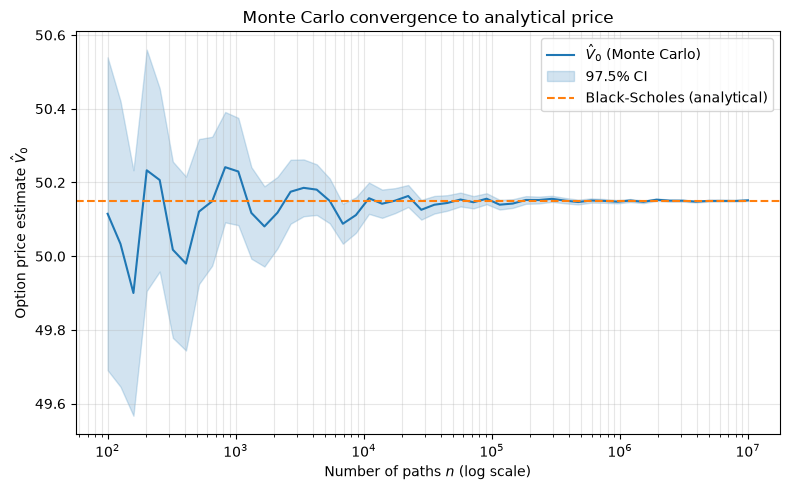

In [5]:
n_vals = np.logspace(2, 7, num=50, dtype=int)
n_vals = np.unique(n_vals)
price_se = pricer.convergence_sweep(n_vals, *params)

significance_level = 0.025
CIs = []
for i in price_se:
    CIs.append(pricer.confidence_interval(*i, level = 1-significance_level))

# 5. Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(n_vals, [price[0] for price in price_se], color='C0', label=r'$\hat{V}_0$ (Monte Carlo)')
ax.fill_between(n_vals, [CI[0] for CI in CIs], [CI[1] for CI in CIs], color='C0', alpha=0.2, label=f'{100*(1-significance_level)}% CI')
ax.axhline(s[0], color='C1', linestyle='--', label='Black-Scholes (analytical)')

ax.set_xscale('log')
ax.set_xlabel('Number of paths $n$ (log scale)')
ax.set_ylabel(r'Option price estimate $\hat{V}_0$')
ax.set_title('Monte Carlo convergence to analytical price')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()